# Reproducing Yates et al. (2017) Figure 3

This notebook reproduces **Figure 3** of Yates, Palmer, Biller & Cockell (2017),
*"Atmospheric Habitable Zones in Y Dwarf Atmospheres"* (ApJ **836**:184,
[doi:10.3847/1538-4357/836/2/184](https://doi.org/10.3847/1538-4357/836/2/184)), using
the output of our standalone 1-D individual-based model (IBM).

Yates Figure 3 shows the **normalized frequency distributions** of the steady-state
organism population in the Atmospheric Habitable Zone (AHZ) across seven quantities:
**altitude, age (in half-lives), density, mass, growth strategy *G*, skin width, and
size (radius)**. Each colored line is one of the 20 ensemble members; the heavy black
line is the ensemble average (the distributions are normalized to integrate to unity).

The data is read from `../ensemble_output/`, produced by `ensemble_launcher.py` for the
control run (convective velocity 1 m s⁻¹, 100 Earth years, 20 members, cold start with
`m_init = 1e-12 kg`).

## 1. Configuration and data loading

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---------------------------------------------------------
ENSEMBLE_DIR  = "../ensemble_output"          # output of ensemble_launcher.py
N_ENS         = 20                            # ensemble members
HALFLIFE_DAYS = 30.0                          # organism half-life (bio_run.nml)
SAVEFIG       = "yates_fig3_reproduction.png"

# state.dat columns:
#   z[m]  mass[kg]  radius[m]  G[-]  rho_org[kg/m3]  age[days]  skin_width[m]
COL = dict(z=0, mass=1, radius=2, G=3, rho=4, age=5, skin=6)

In [2]:
def load_members(ensemble_dir, n_ens):
    """Return a list of (member_id, Nx7 array), one entry per member with data.

    Each state.dat is a single final-step snapshot of the whole population.
    np.genfromtxt(invalid_raise=False) skips any stray truncated line instead of
    aborting; rows that are not finite or not physically sane are then dropped.
    Supports both the per-member layout (member_NN/ensemble_001_state.dat) and the
    legacy flat layout (ensemble_NNN_state.dat).
    """
    members = []
    for k in range(1, n_ens + 1):
        cand = [os.path.join(ensemble_dir, f"member_{k:02d}", "ensemble_001_state.dat"),
                os.path.join(ensemble_dir, f"ensemble_{k:03d}_state.dat")]
        fname = next((c for c in cand if os.path.isfile(c)), None)
        if fname is None:
            print(f"  [skip] member {k:02d}: no state file")
            continue
        data = np.genfromtxt(fname, comments="#", invalid_raise=False)
        if data.ndim == 1:
            data = data[np.newaxis, :]
        good = (np.all(np.isfinite(data), axis=1)
                & (data[:, COL["mass"]] > 0) & (data[:, COL["mass"]] < 1e-8))
        data = data[good]
        if data.shape[0] == 0:
            print(f"  [skip] member {k:02d}: no valid rows")
            continue
        members.append((k, data))
        print(f"  loaded member {k:02d}: {data.shape[0]:>6d} organisms")
    if not members:
        raise SystemExit(f"No state files found in {ensemble_dir} — has the run completed?")
    total = sum(d.shape[0] for _, d in members)
    print(f"\nLoaded {len(members)} members, {total:,} organisms total.")
    return members


members = load_members(ENSEMBLE_DIR, N_ENS)

  loaded member 01: 222252 organisms


  loaded member 02: 210254 organisms


  loaded member 03: 188508 organisms


  loaded member 04: 208707 organisms


  loaded member 05: 181579 organisms


...

  loaded member 16: 209010 organisms


  loaded member 17: 183222 organisms


  loaded member 18: 192483 organisms


  loaded member 19: 234504 organisms


  loaded member 20: 227960 organisms

Loaded 20 members, 4,172,435 organisms total.


## 2. Define the seven Figure 3 quantities

Each quantity is plotted exactly as in Yates Figure 3:

| Panel | x-axis | x scale |
|---|---|---|
| Altitude | km | linear |
| Age | half-lives | linear |
| Density | g cm$^{-3}$ | linear |
| Mass | g | log |
| Strategy ($G$) | – | linear |
| Skin width | cm | log |
| Size (radius) | cm | log |

**All y-axes are logarithmic.** The "normalized frequency" is a probability density
that integrates to unity, so its numerical height depends on the unit it is measured
*per*. Yates expresses the **mass** density **per kilogram** (while labelling the axis
in grams), which is why that panel reaches $\sim\!10^{11}$, and the **length** densities
**per centimetre**, reaching $\sim\!10^{4}$. The remaining panels use the density per
their displayed unit, giving order-unity peaks.

Each entry therefore specifies the values in the *density* unit (`dens`), the factor to
convert those to the displayed *axis* unit (`axis_factor`; only mass differs, kg→g), the
bin edges (log- or linearly spaced in the density unit), the x-scale, and axis ranges
chosen to match the paper's panels.

In [3]:
QUANTITIES = [
    dict(name="Altitude",  axis_unit="Altitude (km)",       xscale="linear",
         dens=lambda d: d[:, COL["z"]] * 1e-3, axis_factor=1.0,
         bins=np.linspace(0, 105, 54), ylim=(1e-3, 2e0)),
    dict(name="Age",       axis_unit="Age (half-lives)",    xscale="linear",
         dens=lambda d: d[:, COL["age"]] / HALFLIFE_DAYS, axis_factor=1.0,
         bins=np.linspace(0, 16, 49), ylim=(1e-5, 2e0)),
    dict(name="Density",   axis_unit="Density (g cm$^{-3}$)", xscale="linear",
         dens=lambda d: d[:, COL["rho"]] * 1e-3, axis_factor=1.0,
         bins=np.linspace(0.5, 1.5, 51), ylim=(1e-3, 2e1)),
    dict(name="Mass",      axis_unit="Mass (g)",            xscale="log",
         dens=lambda d: d[:, COL["mass"]],                  # density per kg (SI)
         axis_factor=1e3,                                   # kg -> g for the axis
         bins=np.logspace(np.log10(5e-12), np.log10(1.5e-10), 60),
         xlim=(1e-10, 3e-7), ylim=(1e-1, 2e11)),
    dict(name="Strategy",  axis_unit="Strategy",            xscale="linear",
         dens=lambda d: d[:, COL["G"]], axis_factor=1.0,
         bins=np.linspace(0, 1, 51), ylim=(1e-3, 2e0)),
    dict(name="Skin width", axis_unit="Skin width (cm)",    xscale="log",
         dens=lambda d: d[:, COL["skin"]] * 1e2,            # m -> cm, density per cm
         axis_factor=1.0,
         bins=np.logspace(np.log10(3e-5), np.log10(3e-3), 60),
         xlim=(3e-5, 3e-3), ylim=(1e-1, 2e4)),
    dict(name="Size",      axis_unit="Size (cm)",           xscale="log",
         dens=lambda d: d[:, COL["radius"]] * 1e2,          # m -> cm, density per cm
         axis_factor=1.0,
         bins=np.logspace(np.log10(7e-4), np.log10(9e-3), 60),
         xlim=(5e-4, 1.5e-2), ylim=(1e0, 2e4)),
]

## 3. Plot

For each quantity we draw one normalized-frequency line per ensemble member (thin,
colored) and the average over members (heavy black), reproducing the structure of
Yates Figure 3.

Saved yates_fig3_reproduction.png


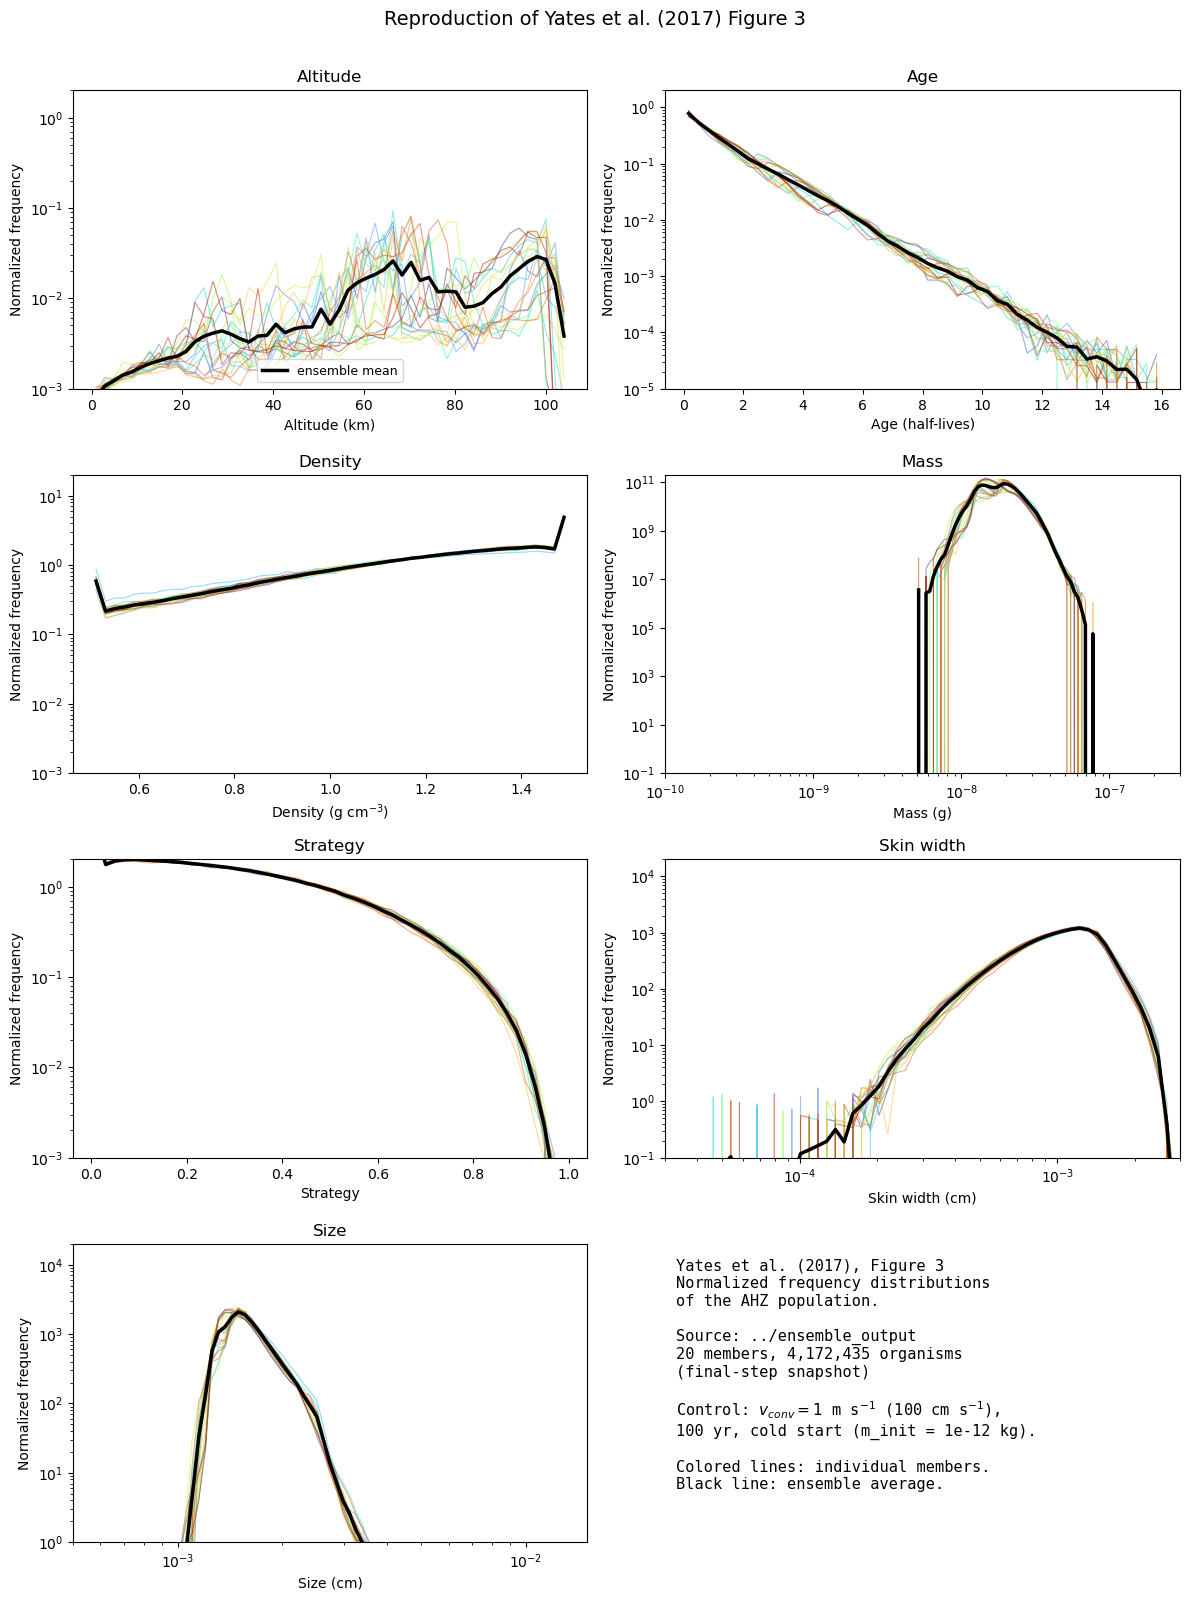

In [4]:
def member_pdf(values, bins):
    """Normalized histogram (integrates to unity) and bin centers, in the
    density unit. density=True divides by bin width, so log-spaced bins give a
    proper per-unit density."""
    h, edges = np.histogram(values, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, h


colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(members)))

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.ravel()

for ax, q in zip(axes, QUANTITIES):
    stack = []
    centers_axis = None
    for (k, data), c in zip(members, colors):
        centers, h = member_pdf(q["dens"](data), q["bins"])
        centers_axis = centers * q["axis_factor"]   # density unit -> display unit
        ax.plot(centers_axis, h, color=c, lw=0.8, alpha=0.5)
        stack.append(h)
    mean_h = np.mean(np.vstack(stack), axis=0)
    ax.plot(centers_axis, mean_h, color="black", lw=2.5, label="ensemble mean")
    ax.set_xscale(q["xscale"])                  # log for mass / skin / size
    ax.set_yscale("log")                        # Yates Fig 3: log frequency axis
    ax.set_xlabel(q["axis_unit"])
    ax.set_ylabel("Normalized frequency")
    ax.set_title(q["name"])
    if "xlim" in q:
        ax.set_xlim(*q["xlim"])
    if "ylim" in q:
        ax.set_ylim(*q["ylim"])

axes[0].legend(loc="lower center", fontsize=9)

# 8th panel: provenance note instead of an empty axis
total = sum(d.shape[0] for _, d in members)
note = axes[len(QUANTITIES)]
note.axis("off")
note.text(0.02, 0.95,
          "Yates et al. (2017), Figure 3\n"
          "Normalized frequency distributions\n"
          "of the AHZ population.\n\n"
          f"Source: {ENSEMBLE_DIR}\n"
          f"{len(members)} members, {total:,} organisms\n"
          "(final-step snapshot)\n\n"
          r"Control: $v_{conv}=1$ m s$^{-1}$ (100 cm s$^{-1}$)," "\n"
          "100 yr, cold start (m_init = 1e-12 kg).\n\n"
          "Colored lines: individual members.\n"
          "Black line: ensemble average.",
          va="top", ha="left", fontsize=11, family="monospace")

fig.suptitle("Reproduction of Yates et al. (2017) Figure 3", fontsize=14, y=0.997)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(SAVEFIG, dpi=150, bbox_inches="tight")
print(f"Saved {SAVEFIG}")
plt.show()

## 4. Summary statistics vs Yates 2017

In [5]:
alld = np.vstack([d for _, d in members])
def col(name):
    return alld[:, COL[name]]

pop_per_member = np.mean([d.shape[0] for _, d in members])

print(f"{'quantity':<18}{'median':>13}{'mean':>13}   Yates 2017")
print("-" * 68)
print(f"{'population/member':<18}{'':>13}{pop_per_member:>13.0f}   free param (food-set)")
print(f"{'mass [g]':<18}{np.median(col('mass'))*1e3:>13.3e}{np.mean(col('mass'))*1e3:>13.3e}   peak ~2e-8 g")
print(f"{'radius [um]':<18}{np.median(col('radius'))*1e6:>13.2f}{np.mean(col('radius'))*1e6:>13.2f}   ~15.6 um")
print(f"{'G [-]':<18}{np.median(col('G')):>13.3f}{np.mean(col('G')):>13.3f}   evolves low")
print(f"{'density [g/cm3]':<18}{np.median(col('rho'))*1e-3:>13.3f}{np.mean(col('rho'))*1e-3:>13.3f}   0.5-1.5")
print(f"{'altitude [km]':<18}{np.median(col('z'))*1e-3:>13.1f}{np.mean(col('z'))*1e-3:>13.1f}   upper AHZ")
print(f"{'age [half-lives]':<18}{np.median(col('age'))/HALFLIFE_DAYS:>13.2f}{np.mean(col('age'))/HALFLIFE_DAYS:>13.2f}   short-lived")

quantity                 median         mean   Yates 2017
--------------------------------------------------------------------
population/member                     208622   free param (food-set)
mass [g]              1.903e-08    1.929e-08   peak ~2e-8 g
radius [um]               15.65        16.26   ~15.6 um
G [-]                     0.238        0.269   evolves low


density [g/cm3]           1.238        1.183   0.5-1.5
altitude [km]              72.4         71.8   upper AHZ
age [half-lives]           0.81         1.26   short-lived
